# Gaming-Player Clustering — How Much Structure Is Really There?

### An unsupervised-learning case study on online-gaming behaviour

**Author:** Blagoy Hristov

---

## Table of contents

1. [Problem understanding, formulation and significance](#sec1)
2. [Mathematical formulation](#sec2)
3. [Data loading and sanity checks](#sec3)
4. [Exploratory data analysis](#sec4)
5. [Feature engineering and preprocessing](#sec5)
6. [Dimensionality and structure check with PCA](#sec6)
7. [K-Means clustering](#sec7)
8. [Choosing *k*: internal validation against a null model](#sec8)
9. [Alternative algorithms: GMM and DBSCAN](#sec9)
10. [External validation and cluster profiling](#sec10)
11. [Conclusions, limitations and future work](#sec11)
12. [References](#refs)

## How to reproduce

```bash
python -m pip install -r requirements.txt
jupyter lab   # then: Kernel ▸ Restart Kernel and Run All Cells
```

**Reproducibility conventions used throughout**

* Every stochastic step is seeded with `random_state = 42`.
* The dataset lives in `data/online_gaming_behavior_dataset.csv`; reusable
  helpers live in `src/clustering_utils.py`.
* The notebook is designed to run top-to-bottom with **Restart & Run All**;
  each cell depends only on cells above it.

<a id="sec3"></a>
## 3. Data loading and sanity checks

We load the dataset and run basic integrity checks (shape, types, missing
values, duplicates, and identifier uniqueness) before any analysis.

In [1]:
import sys
sys.path.insert(0, "src")  # make the reusable helper module importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

import clustering_utils as cu

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
cu.set_plot_style()

pd.set_option("display.max_columns", 20)
print("Libraries loaded. NumPy", np.__version__, "| pandas", pd.__version__)

Libraries loaded. NumPy 2.2.2 | pandas 2.2.3


In [2]:
df = pd.read_csv("data/online_gaming_behavior_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (40034, 13)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [3]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [4]:
# Integrity checks
print("Missing values per column:")
print(df.isna().sum().to_string())
print("\nDuplicate rows          :", int(df.duplicated().sum()))
print("Duplicate PlayerID values:", int(df["PlayerID"].duplicated().sum()))

Missing values per column:
PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0

Duplicate rows          : 0


Duplicate PlayerID values: 0


In [5]:
# Summary statistics of the numeric columns
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
PlayerID,40034.0,29016.50,11556.96,9000.0,19008.25,29016.50,39024.75,49033.0
Age,40034.0,31.99,10.04,15.0,23.00,32.00,41.00,49.0
PlayTimeHours,40034.0,12.02,6.91,0.0,6.07,12.01,17.96,24.0
InGamePurchases,40034.0,0.20,0.40,0.0,0.00,0.00,0.00,1.0
SessionsPerWeek,40034.0,9.47,5.76,0.0,4.00,9.00,14.00,19.0
AvgSessionDurationMinutes,40034.0,94.79,49.01,10.0,52.00,95.00,137.00,179.0
PlayerLevel,40034.0,49.66,28.59,1.0,25.00,49.00,74.00,99.0
AchievementsUnlocked,40034.0,24.53,14.43,0.0,12.00,25.00,37.00,49.0


**Sanity-check verdict.** The dataset is exceptionally clean: 40&nbsp;034 rows,
no missing values, no duplicate rows and a unique `PlayerID`. The `describe`
table already hints at the caveat from Section&nbsp;1 — every numeric feature
has a mean sitting almost exactly at the midpoint of its range (e.g. `Age`
$\approx 32$ on $[15,49]$, `PlayerLevel` $\approx 50$ on $[1,99]$), the signature
of a **uniform** distribution. We test this properly next.

<a id="sec4"></a>
## 4. Exploratory data analysis

The EDA has one central goal: characterise the *geometry* of the data. Three
questions drive it — (a) how are individual features distributed? (b) are
features correlated? (c) what, if anything, distinguishes the `EngagementLevel`
classes?

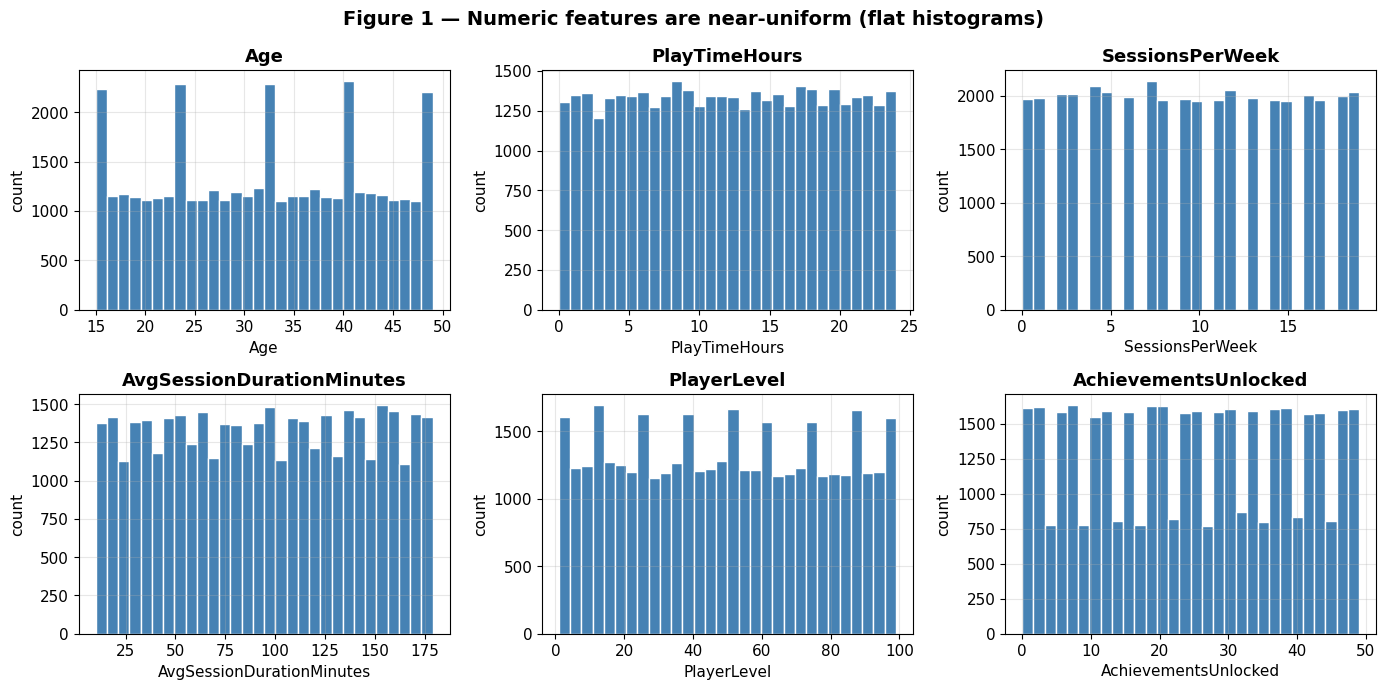

In [6]:
numeric_features = ["Age", "PlayTimeHours", "SessionsPerWeek",
                    "AvgSessionDurationMinutes", "PlayerLevel", "AchievementsUnlocked"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), numeric_features):
    ax.hist(df[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col); ax.set_ylabel("count")
fig.suptitle("Figure 1 — Numeric features are near-uniform (flat histograms)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

**Figure 1.** Every numeric feature is essentially **flat / uniform** over its
range — there are no modes, no gaps, no skew. Real engagement metrics are almost
always right-skewed (a few very heavy users). Uniform histograms are the first
strong sign of synthetic, structureless data.

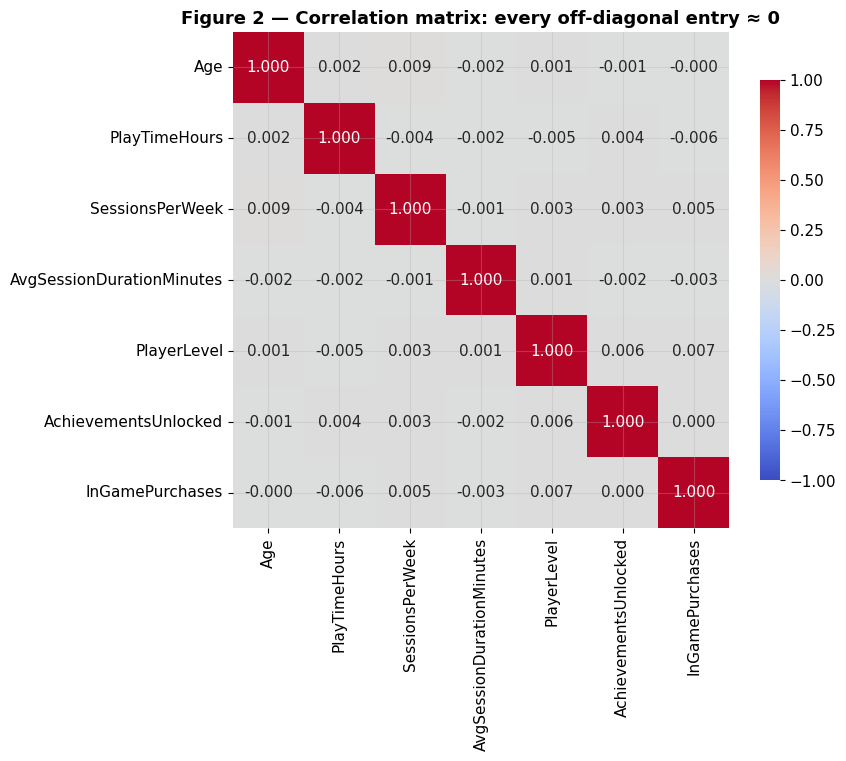

Maximum absolute off-diagonal correlation: 0.0088


In [7]:
# Correlation among numeric behavioural + demographic features (exclude PlayerID)
corr_cols = numeric_features + ["InGamePurchases"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Figure 2 — Correlation matrix: every off-diagonal entry ≈ 0")
plt.show()

off_diag = corr.to_numpy()[~np.eye(len(corr), dtype=bool)]
print(f"Maximum absolute off-diagonal correlation: {np.abs(off_diag).max():.4f}")

**Figure 2.** The largest absolute correlation between any two features is about
**0.009** — effectively zero, so the features are **mutually uncorrelated** (the
correlation matrix is $\approx I$). Together with the near-uniform marginals of
Figure&nbsp;1, this means there is no *linear* low-dimensional structure for PCA
to compress and no correlated "directions" for clusters to form along. (Strict
independence is stronger than zero correlation; the null-model and density tests
in Sections&nbsp;8–9 close that gap by ruling out non-linear structure too.)

In [8]:
# Categorical distributions
categorical_features = ["Gender", "Location", "GameGenre", "GameDifficulty", "EngagementLevel"]
for col in categorical_features:
    counts = df[col].value_counts()
    print(f"{col}:")
    print(counts.to_string())
    print()

Gender:
Gender
Male      23959
Female    16075

Location:
Location
USA       16000
Europe    12004
Asia       8095
Other      3935

GameGenre:
GameGenre
Sports        8048
Action        8039
Strategy      8012
Simulation    7983
RPG           7952

GameDifficulty:
GameDifficulty
Easy      20015
Medium    12011
Hard       8008

EngagementLevel:
EngagementLevel
Medium    19374
High      10336
Low       10324



,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
EngagementLevel,,,,,,
Low,31.90,12.10,4.53,66.88,46.10,22.66
Medium,32.08,11.96,9.55,89.86,50.93,25.22
High,31.92,12.07,14.25,131.92,50.82,25.10


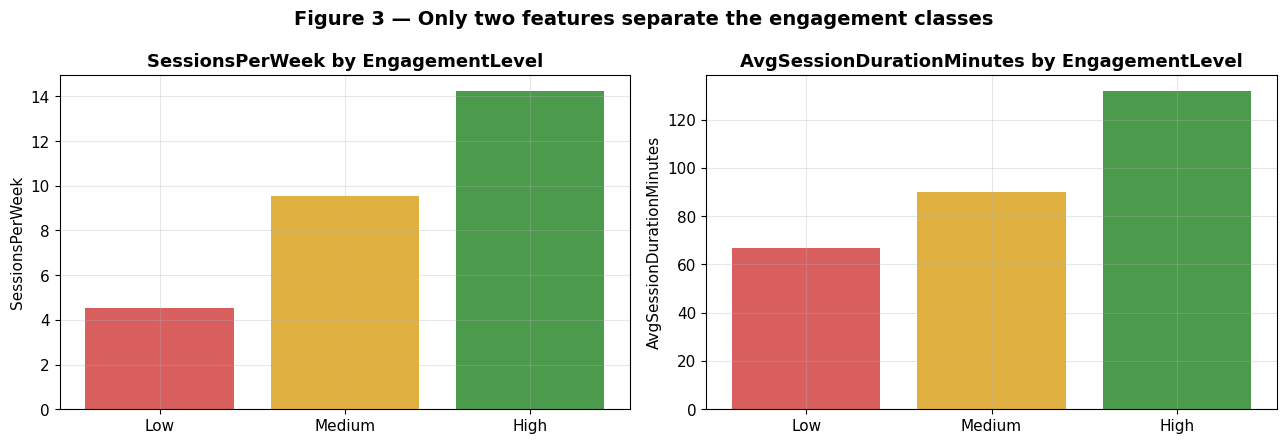

In [9]:
# What separates the EngagementLevel classes? Compare per-class means.
order = ["Low", "Medium", "High"]
group_means = df.groupby("EngagementLevel")[numeric_features].mean().loc[order].round(2)
display(group_means)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col in zip(axes, ["SessionsPerWeek", "AvgSessionDurationMinutes"]):
    ax.bar(order, group_means[col].values, color=["#d95f5f", "#e0b040", "#4c9a4c"])
    ax.set_title(f"{col} by EngagementLevel")
    ax.set_ylabel(col)
fig.suptitle("Figure 3 — Only two features separate the engagement classes",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

**Figure 3 & table.** This is the key EDA finding. Across the three engagement
classes, **only two features change**:

* `SessionsPerWeek`: ~4.5 (Low) → ~9.6 (Medium) → ~14.3 (High)
* `AvgSessionDurationMinutes`: ~67 → ~90 → ~132

Every other feature is essentially flat across classes (a *faint* secondary
gradient appears in `PlayerLevel`/`AchievementsUnlocked` for the Low group, but
it is small). In other words, `EngagementLevel` is — by construction — a
**deterministic threshold on two features**, not an emergent property of the
whole behavioural profile. We will exploit this fact in Section&nbsp;10.